In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

df = pd.read_csv('/content/Dengue3.csv')
df1=df['affected-people-per-day']
n=len(df1)
print(df1.isnull().sum())
df1=df1.reset_index(drop=True)
df1=np.abs(df1.ffill())
#print(df1)

8


In [19]:
#ind_rang = [(0,58),(59,119),(120,180),(181,242),(243,303),(304,364),(365,423),(424,484),(485,545),(546,607),(608,668),(669,729),(730,789),(790,850),(851,911),(912,973),(974,1034),(1035,1095)]
ind_rang=[(0,89),(90,180),(181,272),(273,364),(365,454),(455,545),(546,637),(638,729),(730,820),(821,911),(912,1003),(1004,1095)]
#ind_rang = [(0,119),(120,242),(243,364),(365,484),(485,607),(608,729),(730,850),(851,973),(974,1095)]
#ind_rang =[(0,180),(181,364),(365,545),(545,729),(730,911),(912,1095)]
#ind_rang = [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364),(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729),(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1003,1034),(1035,1064),(1065,1095)]
window = {}

for i, (start, end) in enumerate(ind_rang, start=1):
    window[i]= df1[start:end+1]

In [20]:
#ind1= [(0,30),(31,58),(59,89),(90,119),(120,150),(151,180),(181,211),(212,242),(243,272),(273,303),(304,333),(334,364)]
#ind2 = [(365,395),(396,423),(424,454),(455,484),(485,515),(516,545),(546,576),(577,607),(608,637),(638,668),(669,698),(699,729)]
#ind3  = [(730,760),(761,789),(790,820),(821,850),(851,881),(882,911),(912,942),(943,973),(974,1003),(1004,1034),(1035,1064),(1065,1095)]
#window={}

#for i, (start, end) in enumerate(ind2, start=1):
   # window[i]=df1[start:end+1]

-0.28308977295873183
0.37260729108311563
0.39102047991510525
0.3428699356532636
[0.38628681757775024, 0.3741504775360625, 0.3428699356532636, 0.3672156637001553, 0.37230356624189637, 0.39102047991510525, 0.3684032905500296, 0.3670195150291331, 0.3759836796422963, 0.38076577435991243, 0.37267481978495554, 0.36204350345217223]
The average clustering coeffiecient is: 0.37172812695356106


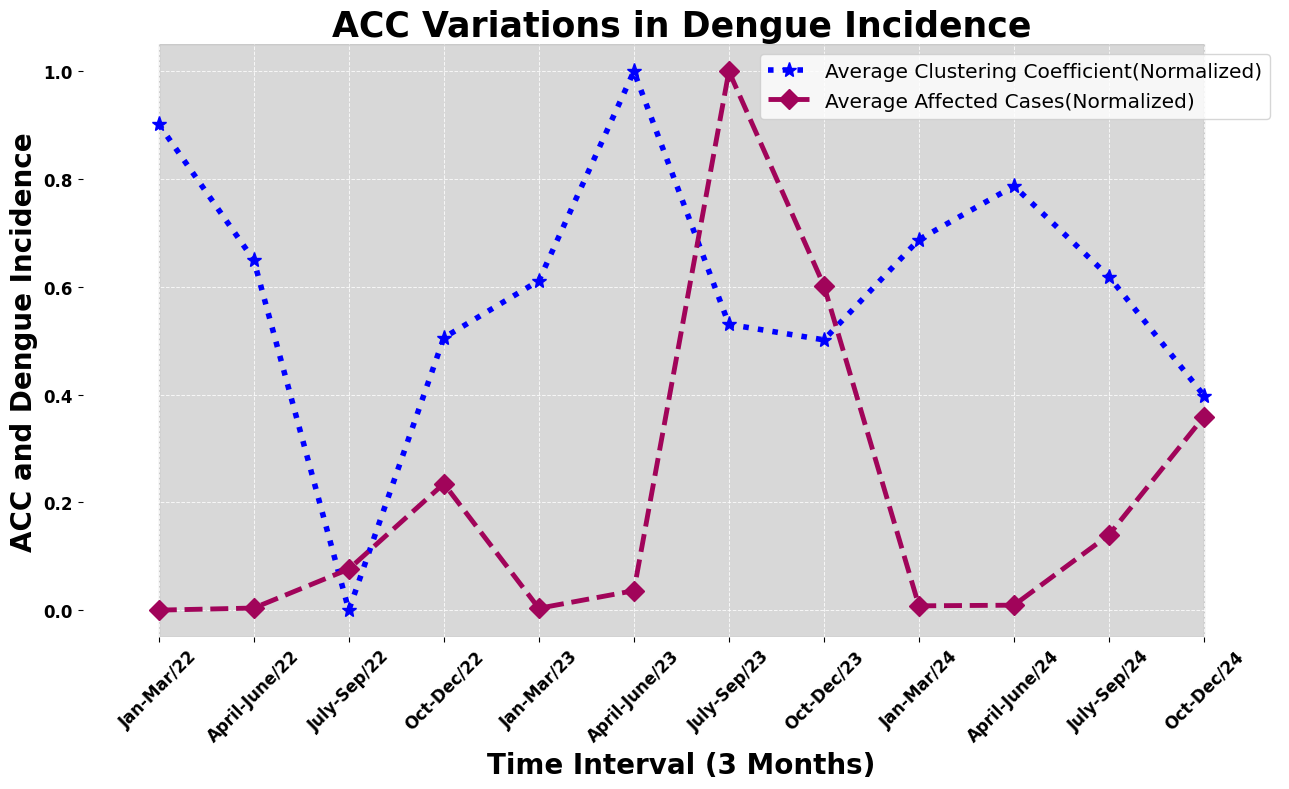

In [21]:
avc = []
average_value1= []

for i in window:
  data=window[i]
  #print(data)
  G= nx.visibility_graph(data)
  N= G.number_of_nodes()
  c_list =[]

  for node in G.nodes():
    neighbors = list(G.neighbors(node))
    n=len(neighbors)
    # Check if n*(n-1) is zero to prevent division by zero
    if n > 1:
        subgraph = G.subgraph(neighbors)
        m=subgraph.number_of_edges()
        c=m/(n*(n-1))
    else:
        c=0
    c_list.append(c)

  if N > 0:
      acc =sum(c_list)/N
  else:
      acc = 0
  avc.append(acc)
  #avc.append(nx.average_clustering(G))
  average_value1.append(data.mean())

r,p = pearsonr(avc, average_value1)

print(r)
print(p)
print(max(avc))
print(min(avc))
print(avc)
scaler= MinMaxScaler()
scaled_value1= scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1=  scaler.fit_transform(np.array(avc).reshape(-1,1))
#print(f'avc:.2f')
#for i in range(0, 12):
  #print(f'{avc[i]:.5f}')
print("The average clustering coeffiecient is:", sum(avc)/len(avc))

fig, ax = plt.subplots(figsize=(13,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), scaled_path1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Average Clustering Coefficient(Normalized)")

ax.plot(range(len(window)), scaled_value1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases(Normalized)")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('ACC and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('ACC Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=14.5,loc='upper right')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

0.6534312084770649
0.02120497438532966
3.8994266602962253
2.258119658119658
[2.499625468164794, 2.601709401709402, 2.6562350692785475, 3.7047300525561395, 2.865168539325843, 2.258119658119658, 3.7955088389870997, 3.1218346870520786, 2.790964590964591, 3.320634920634921, 2.800286669851887, 3.8994266602962253]
The average shortest path length is: 3.0261870464117653


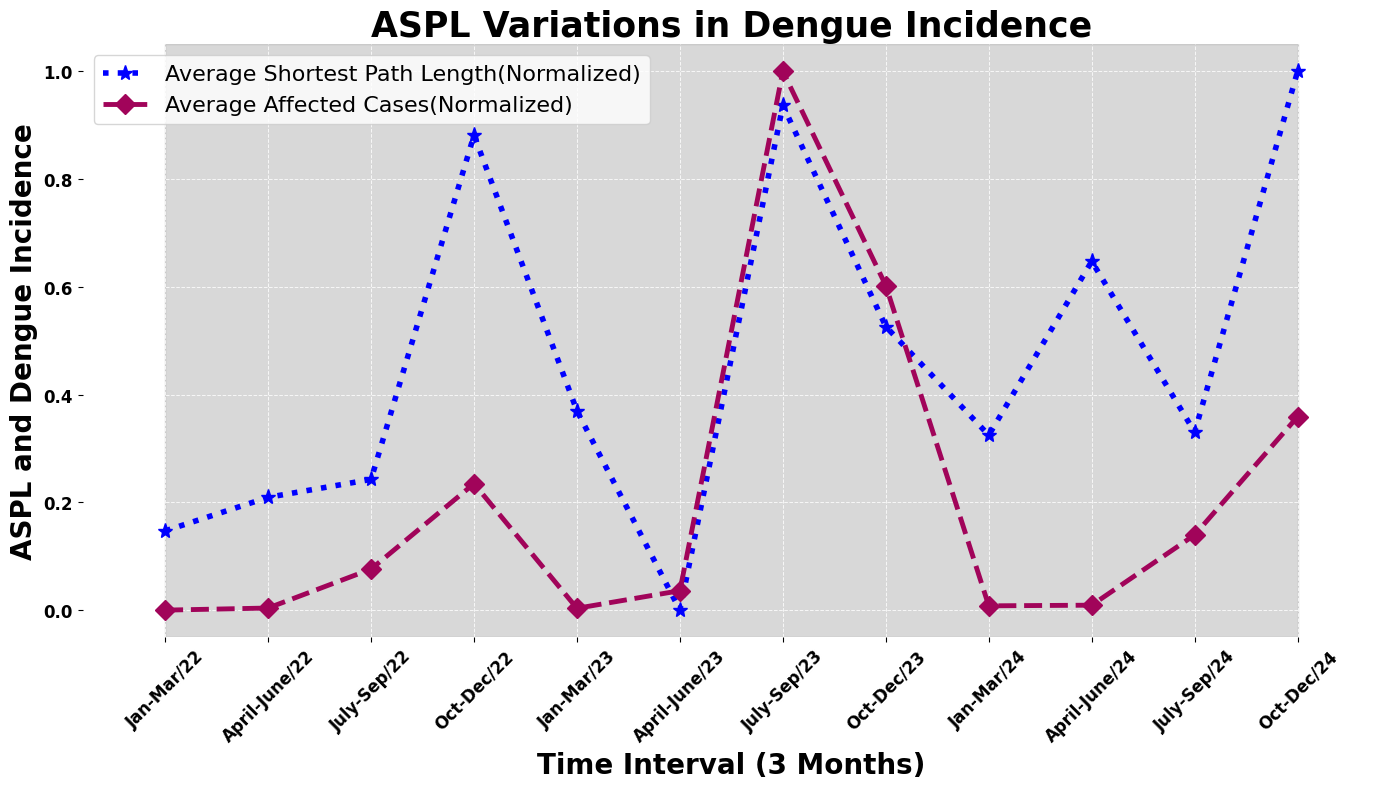

In [22]:
avc = []
average_value1 = []

for i in window:
    data = window[i]

    # Create visibility graph
    G = nx.visibility_graph(data)

    N = G.number_of_nodes()
    total_distance = 0
    count = 0

    # Get shortest path lengths between all pairs
    all_paths = dict(nx.all_pairs_shortest_path_length(G))

    for u in all_paths:
        for v in all_paths[u]:
            if u != v:
                total_distance += all_paths[u][v]
                count += 1

    # Apply formula
    if N > 1:
        L_avg = total_distance / (N * (N - 1))
    else:
        L_avg = 0

    avc.append(L_avg)
    #avc.append(nx.average_shortest_path_length(G))
    average_value1.append(data.mean())

# Scaling
scaler = MinMaxScaler()

scaled_value1 = scaler.fit_transform(np.array(average_value1).reshape(-1,1))
scaled_path1  = scaler.fit_transform(np.array(avc).reshape(-1,1))
r,p = pearsonr(avc, average_value1)

print(r)
print(p)
print(max(avc))
print(min(avc))
#for i in range(0,12):
  #print(f'{avc[i]:.5f}')
print(avc)
print("The average shortest path length is:", sum(avc)/len(avc))
# Plot
fig, ax = plt.subplots(figsize=(14,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), scaled_path1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Average Shortest Path Length(Normalized)")

ax.plot(range(len(window)), scaled_value1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases(Normalized)")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('ASPL and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('ASPL Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

#plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

-0.46464901395509706
0.12803318246592768
0.39035802469135783
0.18107198923525467
[0.30137188065479953, 0.23848765432098773, 0.20308738880167482, 0.19653768523470255, 0.2653242435719395, 0.39035802469135783, 0.18107198923525467, 0.22623504177664336, 0.21301234567901248, 0.22994650205761336, 0.24683009298393935, 0.18667364381650112]
The Global reaching centrality is: 0.2399113744020355


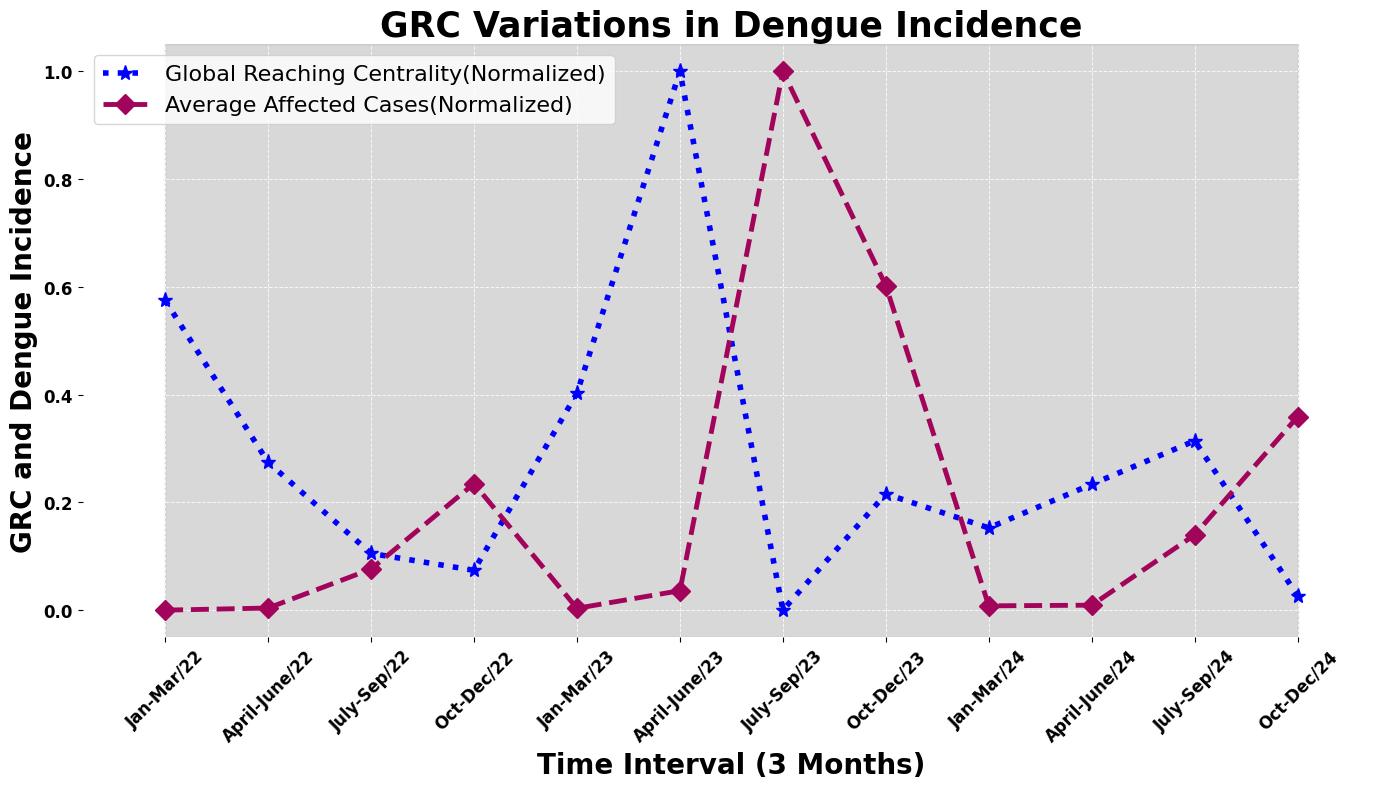

In [23]:
def reaching_centrality(data):

    G = nx.visibility_graph(data)
    N = G.number_of_nodes()

    if N <= 1:
        return 0

    local_CR = []

    # Compute shortest path lengths for all nodes
    all_shortest_paths = dict(nx.all_pairs_shortest_path_length(G))

    for i in G.nodes():

        sum_inverse_distance = 0

        for j in G.nodes():
            if i != j:

                # get distance d(i,j)
                d = all_shortest_paths[i].get(j, 0)

                # avoid division by zero / unreachable nodes
                if d > 0:
                    sum_inverse_distance += 1 / d

        CR_i = sum_inverse_distance / (N - 1)
        local_CR.append(CR_i)

    # ----- Global Reaching Centrality -----

    CR_max = max(local_CR)

    GRC = sum(CR_max - cr for cr in local_CR) / (N - 1)

    return GRC



grc1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  #grc = nx.global_reaching_centrality(G)
  grc = reaching_centrality(data)
  grc1.append(grc)
  avg1.append(data.mean())

sgrc1 = scaler.fit_transform(np.array(grc1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))
r,p = pearsonr(grc1, avg1)

print(r)
print(p)
print(max(grc1))
print(min(grc1))
#for i in range(0,12):
  #print(f'{grc1[i]:.5f}')
print(grc1)
print("The Global reaching centrality is:", sum(grc1)/len(grc1))
fig, ax = plt.subplots(figsize=(14,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), sgrc1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Global Reaching Centrality(Normalized)")

ax.plot(range(len(window)), savg1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases(Normalized)")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('GRC and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('GRC Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

-0.27404845295927205
0.3887138154729616
0.12283272283272283
0.05733397037744864
[0.08114856429463171, 0.08547008547008547, 0.09507883420926899, 0.06497849976110846, 0.06541822721598002, 0.12283272283272283, 0.06282847587195413, 0.09006211180124224, 0.08180708180708181, 0.061782661782661785, 0.07238413760152891, 0.05733397037744864]
The density is: 0.07842711441880958


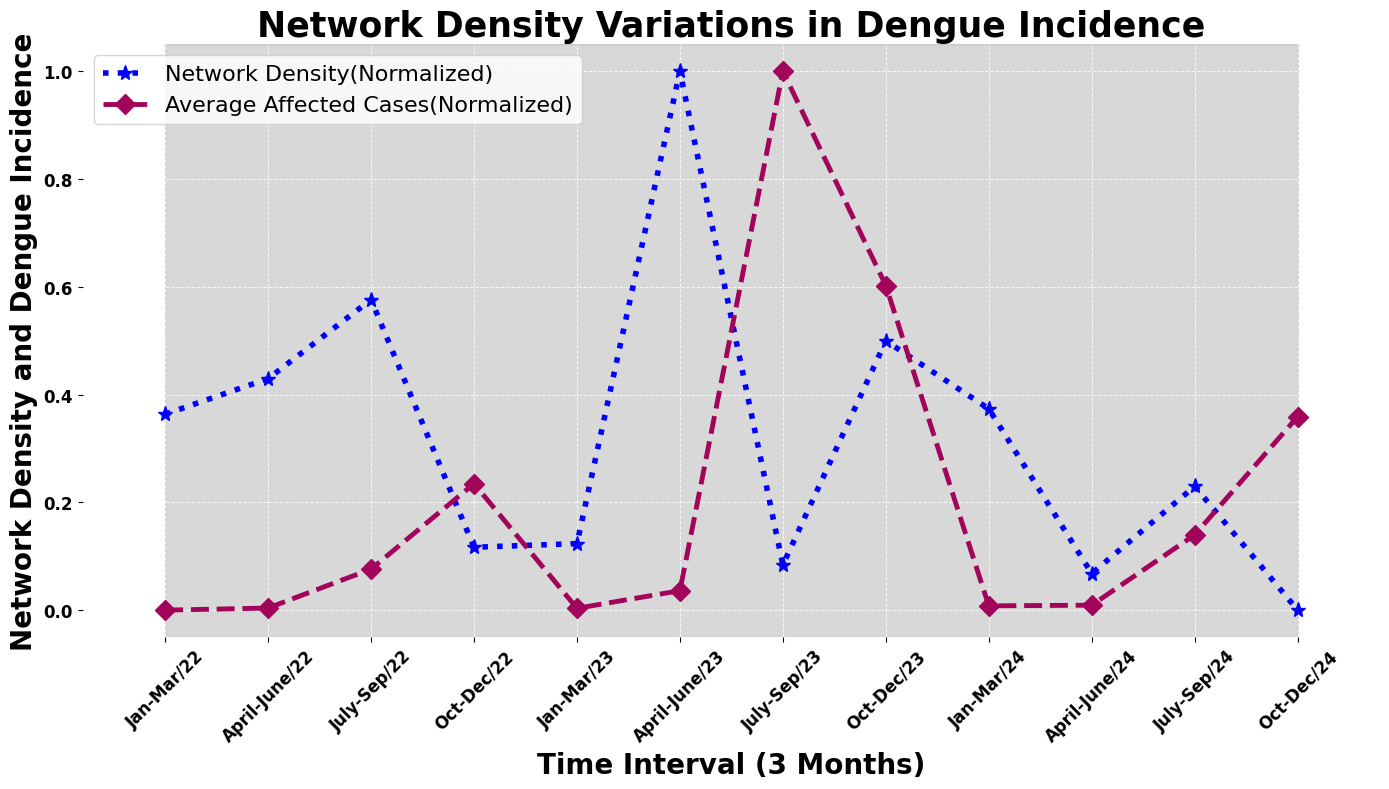

In [24]:


dens1 = []
avg1 = []

for i in window:
  data = window[i]
  #print(data)
  G = nx.visibility_graph(data)
  #dens = nx.density(G)
  N= G.number_of_nodes()
  m= G.number_of_edges()
  dens=(2*m)/(N*(N-1))
  dens1.append(dens)
  avg1.append(data.mean())

sdens1 = scaler.fit_transform(np.array(dens1).reshape(-1,1))
savg1 = scaler.fit_transform(np.array(avg1).reshape(-1,1))
r,p = pearsonr(dens1, avg1)

print(r)
print(p)
print(max(dens1))
print(min(dens1))
#for i in range(0,12):
  #print(f'{dens1[i]:.5f}')
print(dens1)
print("The density is:", sum(dens1)/len(dens1))
#plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(14,8), dpi=100)
ax.axvspan(0, len(window) -1 , color='gray', alpha=0.3)
ax.plot(range(len(window)), sdens1,
        marker='*', markersize=11,
        linewidth=4, linestyle=':',
        color='blue',
        label="Network Density(Normalized)")

ax.plot(range(len(window)), savg1,
        marker='D', markersize=10,
        linewidth=3.5, linestyle='--',
        color='#A1045A',
        label="Average Affected Cases(Normalized)")

month_names = [
    'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
    'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
    'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xlabel('Time Interval (3 Months)', fontsize=20, fontweight='bold')
plt.ylabel('Network Density and Dengue Incidence',
           fontsize=20, fontweight='bold')

plt.title('Network Density Variations in Dengue Incidence',
          fontsize=25, fontweight='bold')

plt.xticks(np.arange(len(month_names)), month_names,
           rotation=45, fontsize=12, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=16, loc='upper left')

plt.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.8)
#plt.xlim(left=0)
#plt.xlim(right=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
#ax.set_xlim(-0.5, len(window)-0.5)
ax.set_xlim(-0.8, len(window)-0.2)
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0.05, y=0.08)
plt.tight_layout()
plt.grid(True, color='white', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_rows', None)
df1

,effected-people-per-day
0,4.0
1,11.0
2,29.0
3,4.0
4,4.0
5,9.0
6,1.0
7,2.0
8,7.0
9,3.0


Z-scores: [np.float64(-1.0570422326457485), np.float64(-4.051306033813144), np.float64(-3.3632208004956943), np.float64(1.7226551282501745), np.float64(-1.2549204411266712), np.float64(-4.66854235504579), np.float64(0.23728744472987634), np.float64(-2.404903063039547), np.float64(-1.6463819760668852), np.float64(0.263535455239131), np.float64(-2.1004913997721824), np.float64(1.6677808716895512)]
2.036505600159533


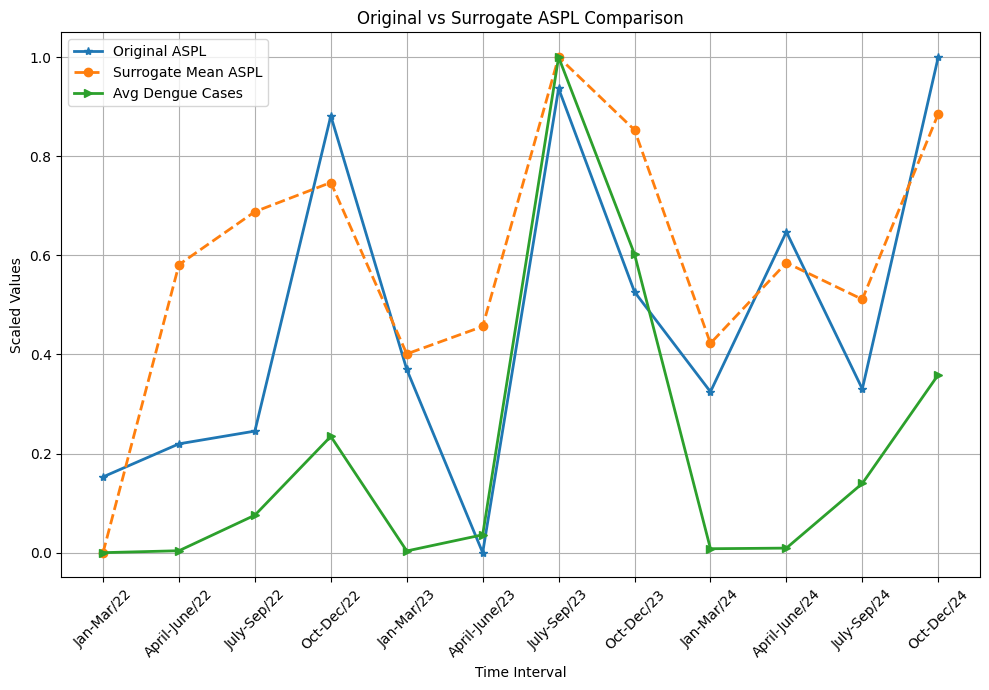

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_aspl(data):
    G = nx.visibility_graph(data)
    return nx.average_shortest_path_length(G)


# ----- Number of surrogates -----
n_surrogates = 200


original_aspl = []
surrogate_mean_aspl = []
surrogate_std_aspl = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_aspl(data)
    original_aspl.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_aspl = compute_aspl(s_data)

        surrogate_vals.append(s_aspl)

    surrogate_mean_aspl.append(np.mean(surrogate_vals))
    surrogate_std_aspl.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_aspl)):
    z = (original_aspl[i] - surrogate_mean_aspl[i]) / surrogate_std_aspl[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_aspl).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_aspl).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original ASPL")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean ASPL")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate ASPL Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Z-scores: [np.float64(-1.4343952435570069), np.float64(-1.9008215951745828), np.float64(-7.436351545087231), np.float64(-0.6443040235292342), np.float64(-3.2193764058091134), np.float64(-1.5903830372553045), np.float64(0.7613815827552267), np.float64(-0.9802765708114504), np.float64(-2.791053923901767), np.float64(0.2643479064171973), np.float64(-2.8220309555457956), np.float64(-0.7067490742819567)]
2.045955988677155


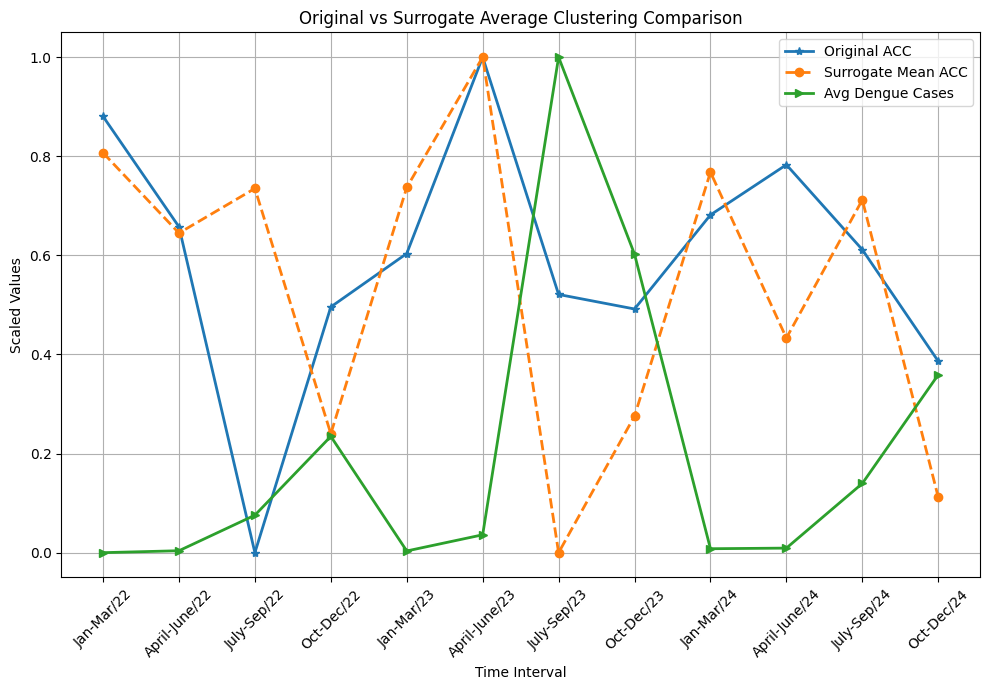

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_aspl(data):
    G = nx.visibility_graph(data)
    return nx.average_clustering(G)

# ----- Number of surrogates -----
n_surrogates = 200


original_aspl = []
surrogate_mean_aspl = []
surrogate_std_aspl = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_aspl(data)
    original_aspl.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_aspl = compute_aspl(s_data)

        surrogate_vals.append(s_aspl)

    surrogate_mean_aspl.append(np.mean(surrogate_vals))
    surrogate_std_aspl.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_aspl)):
    z = (original_aspl[i] - surrogate_mean_aspl[i]) / surrogate_std_aspl[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_aspl).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_aspl).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original ACC")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean ACC")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate Average Clustering Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Z-scores: [np.float64(1.169880372340371), np.float64(6.381013223641632), np.float64(8.90914347105118), np.float64(3.5523820180870245), np.float64(-1.081224552232773), np.float64(12.182135399424567), np.float64(4.100332071730735), np.float64(13.823567608774326), np.float64(3.3190427905235023), np.float64(0.040556284635698645), np.float64(2.1768448368838094), np.float64(0.9797158835820722)]
4.809653209408975


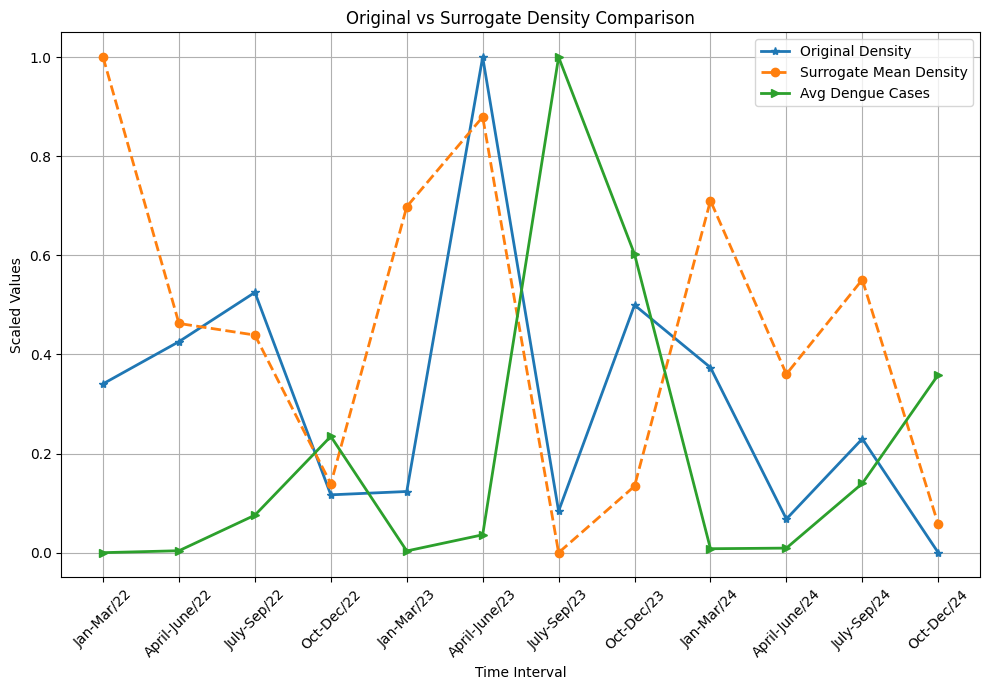

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_aspl(data):
    G = nx.visibility_graph(data)
    return nx.density(G)

# ----- Number of surrogates -----
n_surrogates = 200


original_aspl = []
surrogate_mean_aspl = []
surrogate_std_aspl = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_aspl(data)
    original_aspl.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_aspl = compute_aspl(s_data)

        surrogate_vals.append(s_aspl)

    surrogate_mean_aspl.append(np.mean(surrogate_vals))
    surrogate_std_aspl.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_aspl)):
    z = (original_aspl[i] - surrogate_mean_aspl[i]) / surrogate_std_aspl[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_aspl).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_aspl).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original Density")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean Density")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate Density Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Z-scores: [np.float64(-0.09446596306807754), np.float64(1.2549644818524297), np.float64(1.6925819331833702), np.float64(-0.7752393932833561), np.float64(1.6780732358973984), np.float64(7.510136007802547), np.float64(-0.8816767276516535), np.float64(1.6427836374791402), np.float64(-0.7572766240438688), np.float64(0.2379088527436269), np.float64(1.2124204091646333), np.float64(-0.8517557466659803)]
1.5491069177363401


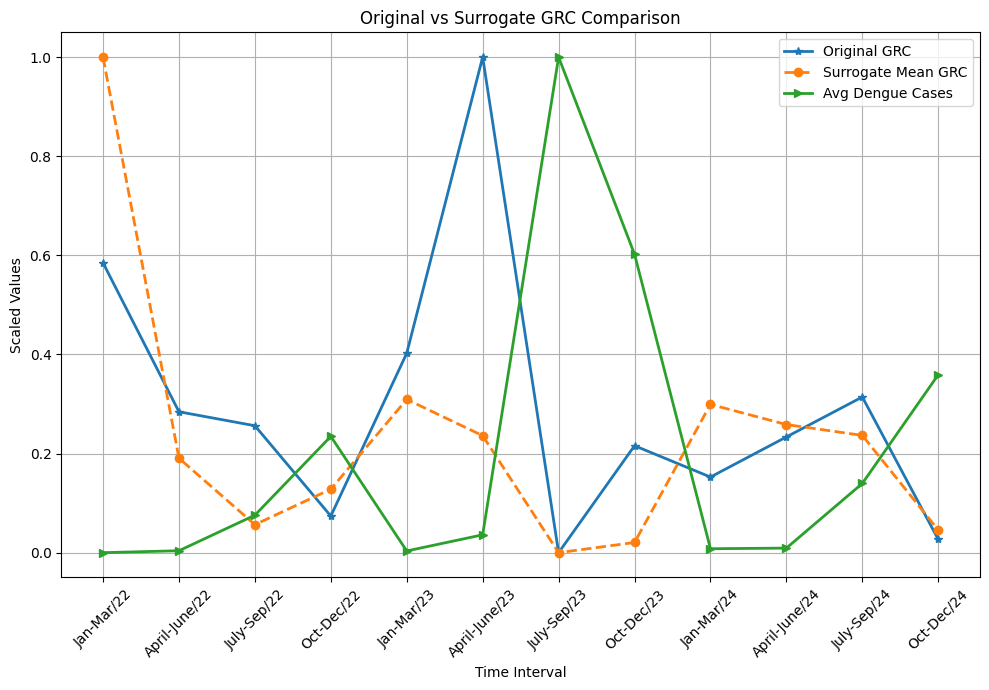

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ----- Function to compute ASPL -----
def compute_grc(data):
    G = nx.visibility_graph(data)
    return nx.global_reaching_centrality(G)

# ----- Number of surrogates -----
n_surrogates = 200


original_grc = []
surrogate_mean_grc = []
surrogate_std_grc = []
average_value1 = []


for i in window:

    data = np.array(window[i])

    # ----- Original -----
    orig_val = compute_grc(data)
    original_grc.append(orig_val)

    average_value1.append(data.mean())

    # ----- Surrogates -----
    surrogate_vals = []

    for k in range(n_surrogates):

        s_data = np.random.permutation(data)   # shuffle surrogate

        s_grc = compute_grc(s_data)

        surrogate_vals.append(s_grc)

    surrogate_mean_grc.append(np.mean(surrogate_vals))
    surrogate_std_grc.append(np.std(surrogate_vals))


# ----- Z-score (Proof) -----
z_scores = []

for i in range(len(original_grc)):
    z = (original_grc[i] - surrogate_mean_grc[i]) / surrogate_std_grc[i]
    z_scores.append(z)

print("Z-scores:", z_scores)
overall_z_score = np.mean(np.abs(z_scores))
print(overall_z_score)

# ----- Scaling -----
scaler = MinMaxScaler()

scaled_original = scaler.fit_transform(np.array(original_grc).reshape(-1,1))
scaled_surrogate = scaler.fit_transform(np.array(surrogate_mean_grc).reshape(-1,1))
scaled_cases = scaler.fit_transform(np.array(average_value1).reshape(-1,1))


# ----- Plot -----
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(range(len(window)), scaled_original,
        marker='*', linewidth=2, label="Original GRC")

ax.plot(range(len(window)), scaled_surrogate,
        marker='o', linewidth=2, linestyle='--', label="Surrogate Mean GRC")

ax.plot(range(len(window)), scaled_cases,
        marker='>', linewidth=2, label="Avg Dengue Cases")


month_names = [
'Jan-Mar/22','April-June/22','July-Sep/22','Oct-Dec/22',
'Jan-Mar/23','April-June/23','July-Sep/23','Oct-Dec/23',
'Jan-Mar/24','April-June/24','July-Sep/24','Oct-Dec/24'
]

plt.xticks(range(len(month_names)), month_names, rotation=45)

plt.xlabel('Time Interval')
plt.ylabel('Scaled Values')
plt.title('Original vs Surrogate GRC Comparison')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()